```text
Case-Study: Mortgages (Germany)
├── Import & Setup
├── Loading
├── Exploring
├── Modelling
│   ├── Pre-processing
│   └── Models  
│            └──Structural
│            └──Structural-Behavioural            
└── Policies
    ├── Define policies
    └── Quantify impact
```

#### Import & Setup

In [1]:
# Init work dir

from pathlib import Path
import sys

# Credit-Risk-Framework
PROJECT_ROOT = Path("/Users/konstantinoskazanas/Downloads/DATA SCIENCE/CREDIT-RISK-FRAMEWORK")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Mortgage case-study
WORK_DIR = Path.cwd()

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import aggregate_dr_on_years
from src.feature_engineering import handle_missing_values
from src.metrics import my_metrics
from src.modelling import estimate_el, estimate_capital
from src.plots import default_capture_curve, my_dr_plot, plot_distribution_by_category, show_correlation, plot_pie_chart
from src.preprocessing import my_time_split
from src.validation import missing_summary
from src.utils import format_policy_table

# ML modules

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import xgboost

#### Loading

In [3]:
# join excel files, drop NA columns, keep Germany

dataset1 = pd.read_excel('../Case Study Dataset/Case Study_dataset 1.xlsx')
dataset2 = pd.read_excel('../Case Study Dataset/Case Study_dataset 2.xlsx')
ds       = pd.concat([dataset1, dataset2], ignore_index=True)
ds       = ds.dropna(axis=1, how="all")
ds       = ds[(ds["CountryOfOrigination"].isin(["Germany"])) & (ds["ProductName"].isin(["General mortgages"]))]
ds       = ds.drop(columns=["CountryOfOrigination", "City", "ProductName"])
print(len(ds))         # Germany & General mortgages: 64.293
#print(ds.info())

64293


#### Exploring 

##### Distribution by category

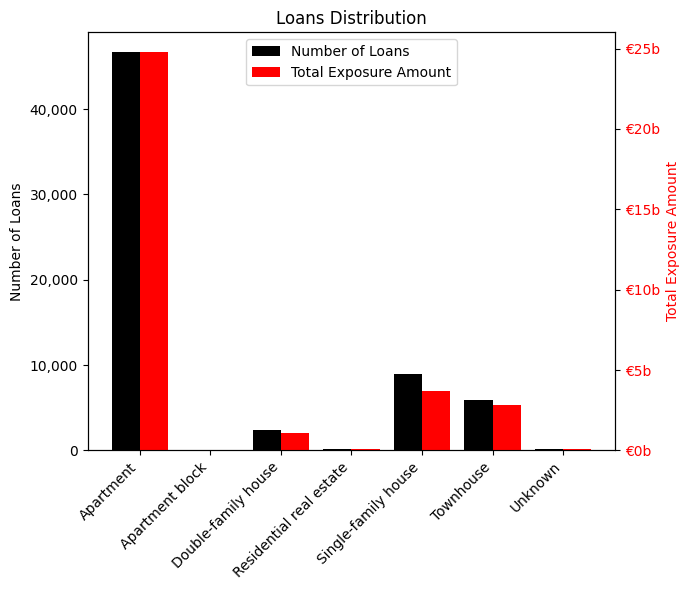

In [4]:
plot_distribution_by_category(ds, category="PropertyType", exposure_column="ExposureAmount")

##### Default Rate per year

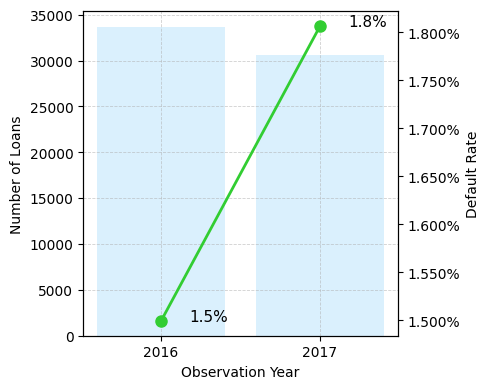

DR (overall):  0.01645591277433002


In [5]:
# plot DR 

dr_summary = aggregate_dr_on_years(ds, "DateOfObservation", "DefaultFlag")
my_dr_plot(dr_summary, 2016, 2017, xlabel="Observation Year")
print('DR (overall): ', ds["DefaultFlag"].mean())

##### LTV

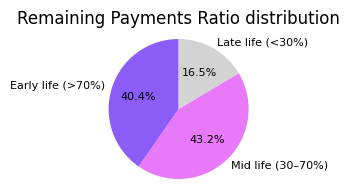

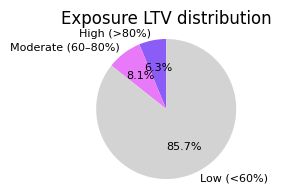

In [6]:
# plot pies

plot_pie_chart(ds, "RemainingPaymentsRatio")
plot_pie_chart(ds, "ExposureLoanToValue")

##### Explore variables

In [7]:
# 1. Target
ds["DefaultFlag"].value_counts(normalize=True)

DefaultFlag
0    0.983544
1    0.016456
Name: proportion, dtype: float64

In [8]:
# 2. Dates
ds["DateOfObservation"].min(), ds["DateOfObservation"].max()

(Timestamp('2016-01-31 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [9]:
# 3. client uniqueness
print(ds.groupby("Client_ID").size().describe())
print(ds["Client_ID"].nunique())

count    62021.000000
mean         1.036633
std          0.192690
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
dtype: float64
62021


## Modelling

### Pre-processing

##### Split

In [10]:
# split

windows = {"train": (2016, 2016), "test":  (2017, 2017)}

splits = my_time_split(ds, "LoanYear", windows, target="DefaultFlag")

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2016 - 2016
Shape (X, y) : (33681, 32), (33681,)

LoanYear distribution
LoanYear
2016    33681
Name: count, dtype: int64

Default rate : 0.0150
------------------------------------------------------------

TEST
Years        : 2017 - 2017
Shape (X, y) : (30612, 32), (30612,)

LoanYear distribution
LoanYear
2017    30612
Name: count, dtype: int64

Default rate : 0.0181
------------------------------------------------------------


##### Map categorical variables

In [11]:
# mapping not needed: set as category type

X_trai["PropertyType"] = X_trai["PropertyType"].astype("category")
X_test["PropertyType"] = X_test["PropertyType"].astype("category")

##### Missing values

In [12]:
# HANDLE MISSING VALUES

X_trai, X_test = handle_missing_values(X_trai, X_test, do_not_handle=["Nr", "DateOfObservation", "Loan_ID", "Client_ID" ])

# summary of missing values after imputation

print(' ')
print('missing values summary after imputation:')
print(missing_summary(X_trai))
print(missing_summary(X_test))

 
missing values summary after imputation:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


##### Feature Groups

In [13]:
# features

features_struc = [
    "PropertyValue",
    "PropertySize",
    "ExposureLoanToValue",
    "TotalCustomerLoanToValue",
    "PropertyType",
    "ExposureAmount",
    "RemainingPaymentsRatio",
    "TimeToMaturity",
    "MaturityRatio",
    "InterestRate",
    "MonthsOnBook",
    "NumberOfExposures",
    ]

features_behav = [
    "DelinquencyFlag",
    "DelinquencyLast3Mon",
    "DelinquencyLast12Mon",
    "30PlusDelinquencyLast3Mon",
    "30PlusDelinquencyLast12Mon",
    "60PlusDelinquencyLast3Mon",
    "60PlusDelinquencyLast12Mon",
    "0_30DelinquencyLast3Mon",
    "0_30DelinquencyLast12Mon",
    "30_60DelinquencyLast3Mon",
    "30_60DelinquencyLast12Mon",
    "60_90DelinquencyLast3Mon",
    "60_90DelinquencyLast12Mon",
    "DaysInDelinquency",
    "ExposureDefaultFlagCount",
    "ClientDefaultFlagCount",
    ]

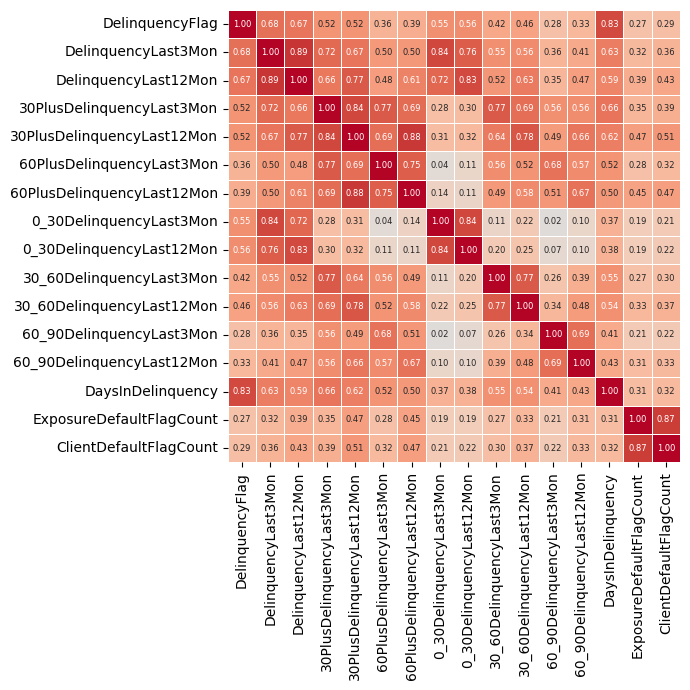


CORRELATION PAIRS ABOVE 0.8:
DelinquencyLast12Mon - DelinquencyLast3Mon: 0.89
30PlusDelinquencyLast12Mon - 30PlusDelinquencyLast3Mon: 0.84
60PlusDelinquencyLast12Mon - 30PlusDelinquencyLast12Mon: 0.88
0_30DelinquencyLast3Mon - DelinquencyLast3Mon: 0.84
0_30DelinquencyLast12Mon - DelinquencyLast12Mon: 0.83
0_30DelinquencyLast12Mon - 0_30DelinquencyLast3Mon: 0.84
DaysInDelinquency - DelinquencyFlag: 0.83
ClientDefaultFlagCount - ExposureDefaultFlagCount: 0.87


In [14]:
# correlation of behavioural features

show_correlation(ds[features_behav])

### Models: model A (structural) - model B (structural + behavioural)

In [15]:
# define model method

model_A = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05, enable_categorical=True, tree_method="hist")
model_B = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05, enable_categorical=True, tree_method="hist")


In [16]:
# MODEL A: reduce feature number

model_A.fit(X_trai[features_struc], y_trai)

# feature importance
importance = pd.Series(model_A.feature_importances_, index=X_trai[features_struc].columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
features_A = sorted.head(22).index.tolist()
# print
print(features_A)

['TotalCustomerLoanToValue', 'ExposureAmount', 'ExposureLoanToValue', 'RemainingPaymentsRatio', 'InterestRate', 'PropertyValue', 'PropertyType', 'PropertySize', 'NumberOfExposures', 'TimeToMaturity', 'MonthsOnBook', 'MaturityRatio']


In [17]:
# MODEL A: fit

model_A.fit(X_trai[features_A], y_trai);

In [18]:
# MODEL B: reduce feature number

model_B.fit(X_trai[features_struc + features_behav], y_trai)

# feature importance
importance = pd.Series(model_B.feature_importances_, index=X_trai[features_struc + features_behav].columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
features_B = sorted.head(22).index.tolist()
# print
print(features_B)

['30PlusDelinquencyLast12Mon', 'DaysInDelinquency', '60PlusDelinquencyLast3Mon', 'DelinquencyLast3Mon', '60PlusDelinquencyLast12Mon', 'DelinquencyLast12Mon', 'ExposureDefaultFlagCount', '0_30DelinquencyLast12Mon', 'PropertyValue', 'RemainingPaymentsRatio', 'TotalCustomerLoanToValue', 'ExposureAmount', '0_30DelinquencyLast3Mon', 'ClientDefaultFlagCount', 'PropertyType', '30_60DelinquencyLast12Mon', 'ExposureLoanToValue', 'PropertySize', 'MonthsOnBook', 'TimeToMaturity', 'MaturityRatio', '30_60DelinquencyLast3Mon']


In [19]:
# MODEL B

model_B.fit(X_trai[features_B], y_trai);

In [20]:
# PREDICTIONS

predictions_model_A_trai = model_A.predict_proba(X_trai[features_A])[:,1]
predictions_model_A_test = model_A.predict_proba(X_test[features_A])[:,1]
predictions_model_B_trai = model_B.predict_proba(X_trai[features_B])[:,1]
predictions_model_B_test = model_B.predict_proba(X_test[features_B])[:,1]

In [21]:
# METRICS

metrics_trai = my_metrics(y_trai, predictions_model_A_trai, exposure=X_trai["ExposureAmount"], dataset_name="Model A (TRAIN)", verbose=True)
metrics_test = my_metrics(y_test, predictions_model_A_test, exposure=X_test["ExposureAmount"], dataset_name="Model A (TEST)" , verbose=True)
print(" Δ GINI  :", (2 * metrics_trai["AUC"] - 1)-(2 * metrics_test["AUC"] - 1))

metrics_trai = my_metrics(y_trai, predictions_model_B_trai, exposure=X_trai["ExposureAmount"], dataset_name="Model B (TRAIN)", verbose=True)
metrics_test = my_metrics(y_test, predictions_model_B_test, exposure=X_test["ExposureAmount"], dataset_name="Model B (TEST)" , verbose=True)
print(" Δ GINI  :", (2 * metrics_trai["AUC"] - 1)-(2 * metrics_test["AUC"] - 1))


----------------------------------------
Model A (TRAIN)
----------------------------------------
AUC         : 0.7280
KS          : 0.3295
Observed DR : 1.50%
Mean PD     : 1.50%
Brier       : 0.0145
Exposure    : 17,291,660,207
----------------------------------------
----------------------------------------
Model A (TEST)
----------------------------------------
AUC         : 0.6441
KS          : 0.2430
Observed DR : 1.81%
Mean PD     : 1.32%
Brier       : 0.0177
Exposure    : 15,200,308,050
----------------------------------------
 Δ GINI  : 0.1678301128368913
----------------------------------------
Model B (TRAIN)
----------------------------------------
AUC         : 0.9367
KS          : 0.7546
Observed DR : 1.50%
Mean PD     : 1.50%
Brier       : 0.0112
Exposure    : 17,291,660,207
----------------------------------------
----------------------------------------
Model B (TEST)
----------------------------------------
AUC         : 0.8163
KS          : 0.5897
Observed DR : 1.81%

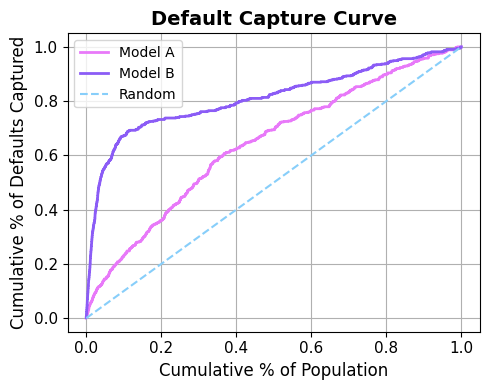

In [22]:
# default capture curves

models = {
    "Model A": predictions_model_A_test, # 
    "Model B": predictions_model_B_test, # chosen
}

curve = default_capture_curve(y_test, models, show=True)

## Policies

### Define Policies

In [23]:
# Portfolio

portfolio = splits["test"]["df"]
portfolio["PD struc"] = predictions_model_A_test
portfolio["PD"]       = predictions_model_B_test
portfolio["LGD"]      = 0.4
portfolio             = estimate_el(portfolio, "LGD", "ExposureAmount")

In [24]:
# no policy

policy_0 = portfolio

# Policy 1: PD based 

policy_1 = portfolio[portfolio["PD"]<0.20]

# Policy 2: Exposure based 

policy_2 = portfolio[portfolio["ExposureLoanToValue"]<0.8]

# Policy 3: Combined 

policy_3 = portfolio[(portfolio["PD"]<0.20) & (portfolio["ExposureLoanToValue"]<0.8)]

# Policies

policies = {"POLICY 0": policy_0, "POLICY 1": policy_1, "POLICY 2": policy_2, "POLICY 3": policy_3,}

### Quantify Impact

In [25]:
# impact: metrics + capital

policy_metrics = {}

for name, policy in policies.items():

    metrics = my_metrics(policy["DefaultFlag"], policy["PD"], exposure=policy["ExposureAmount"], el=policy["EL"], dataset_name=name)

    _, loss_summary, el_summary, _ = estimate_capital(policy, method="monte-carlo", column_lgd="LGD", column_def="DefaultFlag", column_ead="ExposureAmount", show_plot=False)
    el = el_summary["EL (MC-simulated)"]
    ec = loss_summary["Economic Capital"]
    print(f"Monte-Carlo Expected Loss    : {el:,.0f}")
    print(f"Monte-Carlo Economic Capital : {ec:,.0f}")

    policy_metrics[name] = {
        **metrics,
        "Monte-Carlo Expected Loss": el,
        "Monte-Carlo Economic Capital": ec
    }

----------------------------------------
POLICY 0
----------------------------------------
AUC         : 0.8163
KS          : 0.5897
Observed DR : 1.81%
Mean PD     : 1.52%
Brier       : 0.0154
Exposure    : 15,200,308,050
EL Total    : 126,207,029
EL Rate     : 0.83%
----------------------------------------
Monte-Carlo Expected Loss    : 126,256,889
Monte-Carlo Economic Capital : 19,570,487
----------------------------------------
POLICY 1
----------------------------------------
AUC         : 0.7386
KS          : 0.4496
Observed DR : 1.24%
Mean PD     : 0.96%
Brier       : 0.0116
Exposure    : 14,756,657,233
EL Total    : 69,206,324
EL Rate     : 0.47%
----------------------------------------
Monte-Carlo Expected Loss    : 69,121,365
Monte-Carlo Economic Capital : 16,221,720
----------------------------------------
POLICY 2
----------------------------------------
AUC         : 0.8101
KS          : 0.5781
Observed DR : 1.73%
Mean PD     : 1.43%
Brier       : 0.0149
Exposure    : 13,1

In [26]:
# table

policy_table = pd.DataFrame(policy_metrics)
display(format_policy_table(policy_table))

,POLICY 0,POLICY 1,POLICY 2,POLICY 3
Dataset,POLICY 0,POLICY 1,POLICY 2,POLICY 3
AUC,0.816,0.739,0.810,0.736
KS,0.590,0.450,0.578,0.444
Observed_DR,1.81%,1.24%,1.73%,1.22%
Mean_PD,1.52%,0.96%,1.43%,0.93%
Brier,0.015,0.012,0.015,0.011
Exposure,"15,200,308,050","14,756,657,233","13,148,544,250","12,830,898,620"
EL_Total,"126,207,029","69,206,324","96,824,175","56,916,863"
EL_Rate,0.83%,0.47%,0.74%,0.44%
Monte-Carlo Expected Loss,"126,256,889","69,121,365","96,873,075","56,876,552"
